In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
#input_csv = "/content/drive/MyDrive/CREATE Lab/video_agent360/features_person_slot0.csv"

input_dir = Path("/content/drive/MyDrive/CREATE Lab/video_agent360/autocrop_out")
video_files = sorted(input_dir.glob("person_slot*.mp4"))
for vf in video_files:
    print(vf.name)

person_slot0_640x900.mp4
person_slot2_640x900.mp4
person_slot3_640x900.mp4


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

input_dir = Path("/content/drive/MyDrive/CREATE Lab/video360_agent/features")
output_dir = Path("/content/drive/MyDrive/CREATE Lab/video360_agent/behavior_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

feature_files = sorted(input_dir.glob("*_features.csv"))

print("found feature files:")
for f in feature_files:
    print(" -", f.name)

In [ ]:
def infer_behaviors(df, params):
    df = df.copy()

    # -------- interpolation --------
    for col in [
        "yaw_proxy", "pitch_proxy", "smile_score", "mouth_open_score",
        "left_wrist_x", "left_wrist_y", "right_wrist_x", "right_wrist_y",
        "left_wrist_speed", "right_wrist_speed"
    ]:
        if col in df.columns:
            df[col] = df[col].interpolate(limit_direction="both")

    # -------- thresholds --------
    look_down_th = params["look_down_th"]
    look_up_th = params["look_up_th"]
    yaw_left_th = params["yaw_left_th"]
    yaw_right_th = params["yaw_right_th"]
    nod_range_th = params["nod_range_th"]
    nod_window = params["nod_window"]
    smile_th = params["smile_th"]
    mouth_open_th = params["mouth_open_th"]
    wrist_y_th = params["wrist_y_th"]
    wrist_speed_th = params["wrist_speed_th"]

    # -------- head / face --------
    df["look_down_flag"] = df["pitch_proxy"] > look_down_th
    df["look_up_flag"] = df["pitch_proxy"] < look_up_th
    df["turn_left_flag"] = df["yaw_proxy"] < yaw_left_th
    df["turn_right_flag"] = df["yaw_proxy"] > yaw_right_th

    df["pitch_range"] = (
        df["pitch_proxy"].rolling(nod_window, min_periods=5).max()
        - df["pitch_proxy"].rolling(nod_window, min_periods=5).min()
    )
    df["head_nodding_flag"] = df["pitch_range"] > nod_range_th

    df["smiling_flag"] = df["smile_score"] > smile_th
    df["speaking_like_flag"] = df["mouth_open_score"] > mouth_open_th

    # -------- hands / notetaking --------
    df["hand_near_bottom"] = (
        (df["left_wrist_y"] > wrist_y_th) |
        (df["right_wrist_y"] > wrist_y_th)
    )

    df["hand_moving"] = (
        (df["left_wrist_speed"] > wrist_speed_th) |
        (df["right_wrist_speed"] > wrist_speed_th)
    )

    df["take_notes_flag"] = (
        df["look_down_flag"] &
        df["hand_near_bottom"] &
        df["hand_moving"]
    )

    return df

In [ ]:
params = {
    "look_down_th": 1.15,
    "look_up_th": 0.85,
    "yaw_left_th": -0.08,
    "yaw_right_th": 0.08,
    "nod_range_th": 0.18,
    "nod_window": 15,
    "smile_th": 0.42,
    "mouth_open_th": 0.08,
    "wrist_y_th": 0.65,
    "wrist_speed_th": 0.02,
}

all_behavior_dfs = {}

for csv_path in feature_files:
    participant_id = csv_path.stem.replace("_features", "")
    output_csv = output_dir / f"{participant_id}_behaviors.csv"

    print(f"\nProcessing {participant_id} ...")

    df = pd.read_csv(csv_path)
    df = infer_behaviors(df, params)

    df.to_csv(output_csv, index=False)
    all_behavior_dfs[participant_id] = df

    print(f"saved to: {output_csv}")
    print(f"num rows: {len(df)}")

In [ ]:
df_view = all_behavior_dfs["person_slot1_640x900"]

plt.figure(figsize=(14,4))
plt.plot(df_view["t"], df_view["pitch_proxy"], label="pitch_proxy")
plt.plot(df_view["t"], df_view["yaw_proxy"], label="yaw_proxy")
plt.legend()
plt.show()

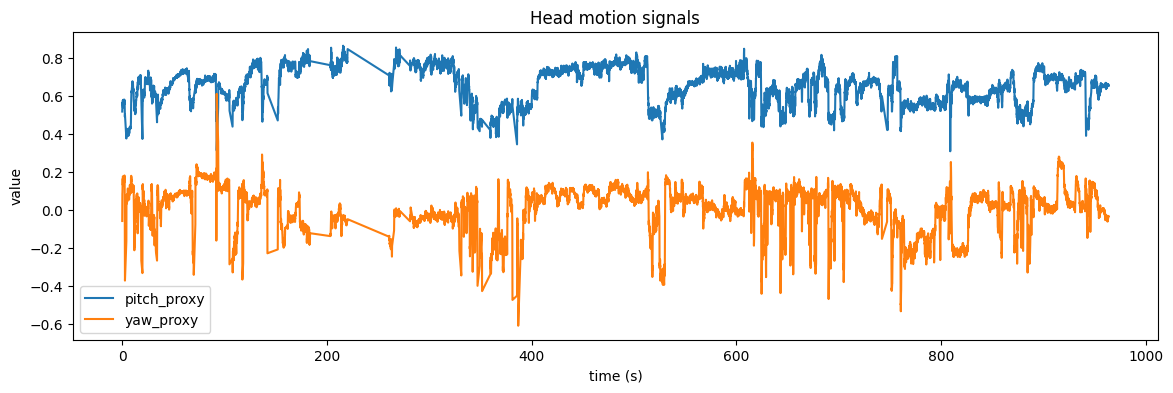

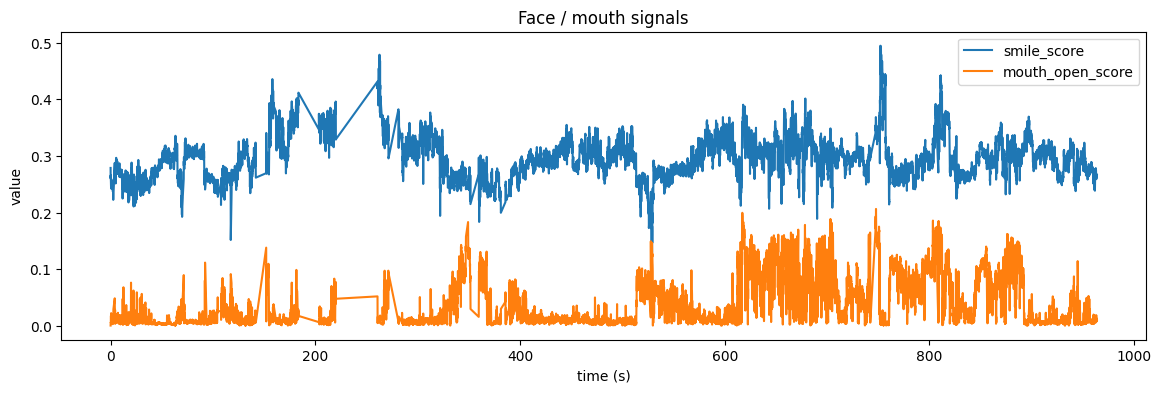

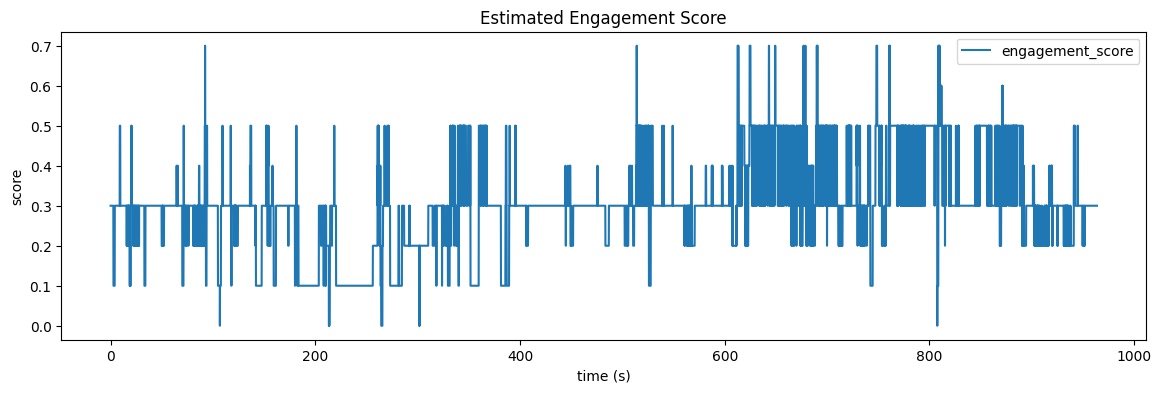

In [ ]:
'''
plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["pitch_proxy"], label="pitch_proxy")
plt.plot(df["t"], df["yaw_proxy"], label="yaw_proxy")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("value")
plt.title("Head motion signals")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["smile_score"], label="smile_score")
plt.plot(df["t"], df["mouth_open_score"], label="mouth_open_score")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("value")
plt.title("Face / mouth signals")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["engagement_score"], label="engagement_score")
plt.xlabel("time (s)")
plt.ylabel("score")
plt.title("Estimated Engagement Score")
plt.legend()
plt.show()
'''

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def sec_to_mmss(x):
    if pd.isna(x):
        return "NA"
    m = int(x // 60)
    s = int(x % 60)
    return f"{m:02d}:{s:02d}"

time_col = "t"

behavior_cols = [
    "look_down_flag",
    "head_nodding_flag",
    "smiling_flag",
    "speaking_like_flag",
    "take_notes_flag"
]

behavior_names = {
    "look_down_flag": "look_down",
    "head_nodding_flag": "nodding",
    "smiling_flag": "smiling",
    "speaking_like_flag": "speaking_like",
    "take_notes_flag": "take_notes"
}

behavior_cols = [c for c in behavior_cols if c in df.columns]

plot_df = df.copy()
plot_df["time_str"] = plot_df[time_col].apply(sec_to_mmss)

def get_active_behaviors(row):
    active = []
    for col in behavior_cols:
        val = row[col]
        if pd.notna(val) and bool(val):
            active.append(behavior_names[col])
    return ", ".join(active) if active else "none"

plot_df["active_behaviors"] = plot_df.apply(get_active_behaviors, axis=1)

fig = go.Figure()

for i, col in enumerate(behavior_cols):
    y_vals = np.where(plot_df[col].fillna(False).astype(bool), i, np.nan)

    fig.add_trace(go.Scatter(
        x=plot_df[time_col],
        y=y_vals,
        mode="markers",
        name=behavior_names[col],
        customdata=plot_df[["time_str", "active_behaviors"]].values,
        hovertemplate=(
            "time: %{customdata[0]}<br>"
            "seconds: %{x:.2f}<br>"
            "active: %{customdata[1]}<br>"
            "<extra></extra>"
        ),
        marker=dict(size=7)
    ))

fig.update_layout(
    title="Interactive Behavior Timeline",
    xaxis_title="time (seconds)",
    yaxis=dict(
        tickmode="array",
        tickvals=list(range(len(behavior_cols))),
        ticktext=[behavior_names[c] for c in behavior_cols]
    ),
    hovermode="x unified",
    height=500,
    width=1400
)

fig.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
output_csv = "video_agent360/features_with_behavior_slot0_v2.csv"
Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_csv, index=False)

print("saved to:", output_csv)
print(df.head())


saved to: video_agent360/features_with_behavior_slot0_v2.csv
   frame_idx         t  face_detected  pose_detected  yaw_proxy  pitch_proxy  \
0          0  0.000000              1              1  -0.057497     0.519073   
1          1  0.068573              1              1   0.049977     0.537860   
2          2  0.137146              1              1   0.086832     0.538086   
3          3  0.205719              1              1   0.091030     0.554598   
4          4  0.274292              1              1   0.125500     0.554111   

   smile_score  mouth_open_score  left_wrist_x  left_wrist_y  ...  \
0     0.278825          0.000337      0.757487      0.893516  ...   
1     0.260075          0.003409      0.757570      0.894371  ...   
2     0.265799          0.006043      0.757565      0.894409  ...   
3     0.259694          0.005194      0.740058      0.883029  ...   
4     0.262697          0.006194      0.706773      0.883450  ...   

   take_notes_flag  look_down_ratio_notes  